#**Scalable Processing of NYC Motor Vehicle Collision Data using Apache Spark**

**Dataset Selection:**
Motor Vehicle Collisions - Crashes

**Source**: NYC Open Data (City of New York) https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data

**Filename**: Motor_Vehicle_Collisions_-_Crashes_20260310.csv


---

### **OUTLINE**

- **Part 1:** Batch Processing
  - Load & Inspect Data
  - Data Cleaning & Preprocessing
  - Data Analysis
    - DataFrame Analytics
    - Spark SQL
    - Window Functions
- **Part 2:** Streaming
  - Simulate Live Data Feed
  - Define Schema & Run Streaming Query
  - Save Aggregations to Parquet (Google Drive)
- **Part 3:** Visualization


---



### Install Java & PySpark

In [1]:
!apt-get install openjdk-17-jdk-headless -qq
!pip install -q pyspark==3.5.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 11.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.


In [2]:

import os, sys
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NYC_Collision_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.driver.extraJavaOptions", "-Djava.io.tmpdir=/tmp") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

spark

## Part 1: Batch Processing
- ### Load & Inspect Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Loading Data from Google Drive

#Spark DataFrames
#Load and Inspect Data
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/content/drive/MyDrive/BigData/Motor_Vehicle_Collisions_-_Crashes_20260310.csv")

#Print schema and show sample 5 rows
#check rows and columns count
print(f"Total rows    : {df.count():,}")
print(f"Total columns : {len(df.columns)}")
df.printSchema()
df.show(5)


Total rows    : 2,247,389
Total columns : 29
root
 |-- CRASH DATE: string (nullable = true)
 |-- CRASH TIME: string (nullable = true)
 |-- BOROUGH: string (nullable = true)
 |-- ZIP CODE: string (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- LONGITUDE: double (nullable = true)
 |-- LOCATION: string (nullable = true)
 |-- ON STREET NAME: string (nullable = true)
 |-- CROSS STREET NAME: string (nullable = true)
 |-- OFF STREET NAME: string (nullable = true)
 |-- NUMBER OF PERSONS INJURED: string (nullable = true)
 |-- NUMBER OF PERSONS KILLED: integer (nullable = true)
 |-- NUMBER OF PEDESTRIANS INJURED: integer (nullable = true)
 |-- NUMBER OF PEDESTRIANS KILLED: integer (nullable = true)
 |-- NUMBER OF CYCLIST INJURED: integer (nullable = true)
 |-- NUMBER OF CYCLIST KILLED: string (nullable = true)
 |-- NUMBER OF MOTORIST INJURED: string (nullable = true)
 |-- NUMBER OF MOTORIST KILLED: integer (nullable = true)
 |-- CONTRIBUTING FACTOR VEHICLE 1: string (nullable = tr

- ### Data Cleaning & Preprocessing

In [5]:
from pyspark.sql.functions import col, to_timestamp, concat_ws, year, month, hour

#analysis will be focused by Borough and time-series; Location is just concatenation of Latitude and Longitude which si redundant
#Drop only the redundant/unused columns
COLUMNS_TO_DROP = [
    "CROSS STREET NAME",
    "OFF STREET NAME",
    "LOCATION"
]

df_selected = df.drop(*COLUMNS_TO_DROP)
print(f"Columns after dropping : {len(df_selected.columns)}")
print(f"Columns kept           : {df_selected.columns}")

Columns after dropping : 26
Columns kept           : ['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'ON STREET NAME', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5', 'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5']


In [6]:
#Check null counts per column
from pyspark.sql.functions import sum as spark_sum

print("Null counts per column:")
df_selected.select(
    [spark_sum(col(c).isNull().cast("int")).alias(c) for c in df_selected.columns]
).show(truncate=False)

Null counts per column:
+----------+----------+-------+--------+--------+---------+--------------+-------------------------+------------------------+-----------------------------+----------------------------+-------------------------+------------------------+--------------------------+-------------------------+-----------------------------+-----------------------------+-----------------------------+-----------------------------+-----------------------------+------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|CRASH DATE|CRASH TIME|BOROUGH|ZIP CODE|LATITUDE|LONGITUDE|ON STREET NAME|NUMBER OF PERSONS INJURED|NUMBER OF PERSONS KILLED|NUMBER OF PEDESTRIANS INJURED|NUMBER OF PEDESTRIANS KILLED|NUMBER OF CYCLIST INJURED|NUMBER OF CYCLIST KILLED|NUMBER OF MOTORIST INJURED|NUMBER OF MOTORIST KILLED|CONTRIBUTING FACTOR VEHICLE 1|CONTRIBUTING FACTOR VEHICLE 2|CONTRIBUTING FACTOR VEHICLE 3|CONTRIBUTING FACTOR VEHICLE 4|CONTRIBUTING FAC

In [7]:
from pyspark.sql.functions import col, to_timestamp, concat_ws, year, month, hour
from pyspark.sql.types import IntegerType

#Combine CRASH DATE and CRASH TIME into a single timestamp column for time-based aggregations
#Extract Year, Month and Hour for time-based aggregations
#Convert string type to integer for count analysis
df_with_ts = df_selected \
    .withColumn(
        "CRASH_TIMESTAMP",
        to_timestamp(concat_ws(" ", col("CRASH DATE"), col("CRASH TIME")), "MM/dd/yyyy H:mm")
    ) \
    .withColumn("NUMBER OF PERSONS INJURED", col("NUMBER OF PERSONS INJURED").cast(IntegerType())) \
    .withColumn("NUMBER OF CYCLIST KILLED", col("NUMBER OF CYCLIST KILLED").cast(IntegerType())) \
    .withColumn("NUMBER OF MOTORIST INJURED", col("NUMBER OF MOTORIST INJURED").cast(IntegerType()))

#Extract useful time parts
df_with_ts = df_with_ts \
    .withColumn("CRASH_YEAR",  year(col("CRASH_TIMESTAMP"))) \
    .withColumn("CRASH_MONTH", month(col("CRASH_TIMESTAMP"))) \
    .withColumn("CRASH_HOUR",  hour(col("CRASH_TIMESTAMP")))

#Verify the new columns
df_with_ts.select(
    "CRASH DATE", "CRASH TIME", "CRASH_TIMESTAMP", "CRASH_YEAR", "CRASH_HOUR",
    "NUMBER OF PERSONS INJURED", "NUMBER OF CYCLIST KILLED", "NUMBER OF MOTORIST INJURED"
).show(5)

+----------+----------+-------------------+----------+----------+-------------------------+------------------------+--------------------------+
|CRASH DATE|CRASH TIME|    CRASH_TIMESTAMP|CRASH_YEAR|CRASH_HOUR|NUMBER OF PERSONS INJURED|NUMBER OF CYCLIST KILLED|NUMBER OF MOTORIST INJURED|
+----------+----------+-------------------+----------+----------+-------------------------+------------------------+--------------------------+
|09/11/2021|      2:39|2021-09-11 02:39:00|      2021|         2|                        2|                       0|                         2|
|03/26/2022|     11:45|2022-03-26 11:45:00|      2022|        11|                        1|                       0|                         1|
|11/01/2023|      1:29|2023-11-01 01:29:00|      2023|         1|                        1|                       0|                         1|
|06/29/2022|      6:55|2022-06-29 06:55:00|      2022|         6|                        0|                       0|                    

In [8]:
#Drop rows with nulls in critical columns and filter invalid records
initial_count = df_with_ts.count()
print(f"Rows before cleaning: {initial_count:,}")

#drop rows with null values in critical fields for analysis
df_clean = df_with_ts.dropna(subset=[
    "CRASH_TIMESTAMP",
    "BOROUGH",
    "NUMBER OF PERSONS INJURED"
])

#Filter logical data only
#exclude negative values for person count and Year outside 2012-2025 range
df_clean = df_clean.filter(
    (col("NUMBER OF PERSONS INJURED") >= 0) &
    (col("NUMBER OF PERSONS KILLED")  >= 0) &
    (col("CRASH_YEAR") >= 2012) &
    (col("CRASH_YEAR") <= 2025)
)

final_count = df_clean.count()
print(f"Rows after cleaning  : {final_count:,}")
print(f"Records removed      : {initial_count - final_count:,}")

Rows before cleaning: 2,247,389
Rows after cleaning  : 1,550,033
Records removed      : 697,356


- ### Where Do Crashes Happen?
(DataFrame Analytics - Borough & Fatality Analysis)


In [9]:
from pyspark.sql.functions import count, desc, asc, avg, sum as spark_sum, round

#1.Total crashes by borough
print("1. Total Crashes by Borough:")
df_clean.groupBy("BOROUGH") \
    .count() \
    .orderBy(desc("count")) \
    .show()

#2.Average injuries per crash by borough
print("2. Average Injuries per Crash by Borough:")
df_clean.groupBy("BOROUGH") \
    .agg(
        round(avg("NUMBER OF PERSONS INJURED"), 2).alias("avg_injuries_per_crash")
    ) \
    .orderBy(desc("avg_injuries_per_crash")) \
    .show()

#3.Yearly crash trend (2012-2025) - aggregation over time
print("3. Yearly Crash Trend (2012–2025):")
df_clean.groupBy("CRASH_YEAR") \
    .count() \
    .orderBy(asc("CRASH_YEAR")) \
    .show(20)

#4.Filter: Fatal crashes only - aggregation over location
print("4. Fatal Crashes by Borough:")
df_clean.filter(col("NUMBER OF PERSONS KILLED") > 0) \
    .groupBy("BOROUGH") \
    .agg(
        count("*").alias("fatal_crashes"),
        spark_sum("NUMBER OF PERSONS KILLED").alias("total_killed")
    ) \
    .orderBy(desc("fatal_crashes")) \
    .show()

1. Total Crashes by Borough:
+-------------+------+
|      BOROUGH| count|
+-------------+------+
|     BROOKLYN|497094|
|       QUEENS|415325|
|    MANHATTAN|343176|
|        BRONX|229544|
|STATEN ISLAND| 64894|
+-------------+------+

2. Average Injuries per Crash by Borough:
+-------------+----------------------+
|      BOROUGH|avg_injuries_per_crash|
+-------------+----------------------+
|     BROOKLYN|                  0.35|
|        BRONX|                  0.35|
|       QUEENS|                  0.32|
|STATEN ISLAND|                   0.3|
|    MANHATTAN|                  0.23|
+-------------+----------------------+

3. Yearly Crash Trend (2012–2025):
+----------+------+
|CRASH_YEAR| count|
+----------+------+
|      2012| 77576|
|      2013|155981|
|      2014|156356|
|      2015|163474|
|      2016|153304|
|      2017|142942|
|      2018|149221|
|      2019|137024|
|      2020| 73688|
|      2021| 72223|
|      2022| 68787|
|      2023| 65729|
|      2024| 65230|
|      2025| 6

- ### When & Why Do Crashes Happen?
(Spark SQL - Time, Factors & Vehicle Analysis)

In [10]:
# Register as temporary view
df_clean.createOrReplaceTempView("collisions")

# 1. Peak crash hours
print("1. Peak Crash Hours:")
spark.sql("""
    SELECT CRASH_HOUR, COUNT(*) as crash_count
    FROM collisions
    GROUP BY CRASH_HOUR
    ORDER BY crash_count DESC
""").show()

# 2. Top 10 contributing factors across ALL vehicles (1-5)
# We use UNION ALL to combine all 5 vehicle factor columns into one column
# before aggregating — this ensures multi-vehicle crashes are fully counted
print("2. Top 10 Contributing Factors (all vehicles combined):")
spark.sql("""
    SELECT factor, COUNT(*) as crash_count
    FROM (
        SELECT `CONTRIBUTING FACTOR VEHICLE 1` as factor FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 2` FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 3` FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 4` FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 5` FROM collisions
    )
    WHERE factor IS NOT NULL
      AND factor != 'Unspecified'
    GROUP BY factor
    ORDER BY crash_count DESC
    LIMIT 10
""").show(truncate=False)

# 3. Top 10 vehicle types involved across ALL vehicles (1-5)
print("3. Top 10 Vehicle Types Involved (all vehicles combined):")
spark.sql("""
    SELECT vehicle_type, COUNT(*) as count
    FROM (
        SELECT `VEHICLE TYPE CODE 1` as vehicle_type FROM collisions
        UNION ALL
        SELECT `VEHICLE TYPE CODE 2` FROM collisions
        UNION ALL
        SELECT `VEHICLE TYPE CODE 3` FROM collisions
        UNION ALL
        SELECT `VEHICLE TYPE CODE 4` FROM collisions
        UNION ALL
        SELECT `VEHICLE TYPE CODE 5` FROM collisions
    )
    WHERE vehicle_type IS NOT NULL
    GROUP BY vehicle_type
    ORDER BY count DESC
    LIMIT 10
""").show(truncate=False)

# 4. Crashes by borough and hour (cross analysis)
print("4. Top Borough + Hour Combinations:")
spark.sql("""
    SELECT BOROUGH, CRASH_HOUR, COUNT(*) as crash_count
    FROM collisions
    GROUP BY BOROUGH, CRASH_HOUR
    ORDER BY crash_count DESC
    LIMIT 10
""").show()

1. Peak Crash Hours:
+----------+-----------+
|CRASH_HOUR|crash_count|
+----------+-----------+
|        16|     110921|
|        17|     108300|
|        14|     104296|
|        15|      96705|
|        18|      96043|
|        13|      91060|
|        12|      87032|
|         8|      85352|
|         9|      82231|
|        11|      81638|
|        19|      79811|
|        10|      77990|
|        20|      67242|
|        21|      56938|
|        22|      50992|
|         0|      49319|
|         7|      45278|
|        23|      41408|
|         6|      31713|
|         1|      26184|
+----------+-----------+
only showing top 20 rows

2. Top 10 Contributing Factors (all vehicles combined):
+------------------------------+-----------+
|factor                        |crash_count|
+------------------------------+-----------+
|Driver Inattention/Distraction|372902     |
|Failure to Yield Right-of-Way |112738     |
|Other Vehicular               |77964      |
|Backing Unsafely          

- ### How Have Crashes Changed Over Time?
(Window Functions - Year-over-Year Trend)

In [11]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag

#Aggregate: yearly crash count per borough
yearly_borough = df_clean.groupBy("CRASH_YEAR", "BOROUGH") \
    .agg(count("*").alias("crash_count"))

#Partition by borough, order by year (lag() looks at the previous year)
window_yoy = Window.partitionBy("BOROUGH").orderBy("CRASH_YEAR")

yoy_trend = yearly_borough \
    .withColumn("prev_year_count", lag("crash_count", 1).over(window_yoy)) \
    .withColumn("yoy_change", col("crash_count") - col("prev_year_count"))

#Show trend for all boroughs
print("Year-over-year crash count change by borough:")
yoy_trend.orderBy(asc("BOROUGH"), asc("CRASH_YEAR")).show(50)

#Highlight the largest single-year drops - shows pandemic trend
print("\nLargest year-over-year drops:")
yoy_trend.filter(col("yoy_change").isNotNull()) \
    .orderBy(asc("yoy_change")) \
    .show(10)

Year-over-year crash count change by borough:
+----------+---------+-----------+---------------+----------+
|CRASH_YEAR|  BOROUGH|crash_count|prev_year_count|yoy_change|
+----------+---------+-----------+---------------+----------+
|      2012|    BRONX|       9511|           NULL|      NULL|
|      2013|    BRONX|      19768|           9511|     10257|
|      2014|    BRONX|      19688|          19768|       -80|
|      2015|    BRONX|      21258|          19688|      1570|
|      2016|    BRONX|      21660|          21258|       402|
|      2017|    BRONX|      21395|          21660|      -265|
|      2018|    BRONX|      23055|          21395|      1660|
|      2019|    BRONX|      22437|          23055|      -618|
|      2020|    BRONX|      14306|          22437|     -8131|
|      2021|    BRONX|      13389|          14306|      -917|
|      2022|    BRONX|      12285|          13389|     -1104|
|      2023|    BRONX|      10507|          12285|     -1778|
|      2024|    BRONX|  

## Part 2: Structured Streaming (Simulated)

In [12]:
#clean restart for streaming
import shutil
shutil.rmtree('collision_stream_input',      ignore_errors=True)
shutil.rmtree('collision_stream_checkpoint', ignore_errors=True)
print("Streaming folders cleared.")

Streaming folders cleared.


- ### Simulate Live Data Feed

In [13]:
import os
os.makedirs('collision_stream_input', exist_ok=True)

#Selected columns for streaming
STREAM_COLS = [
    "CRASH_TIMESTAMP",
    "BOROUGH",
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED"
]

df_stream_source = df_clean.select(STREAM_COLS).dropna()

#Use df_stream_source for simulating feed
NUM_BATCHES = 5
partitions = df_stream_source.randomSplit([1.0] * NUM_BATCHES, seed=42)

for i, partition in enumerate(partitions):
    partition.toPandas().to_csv(
        f"collision_stream_input/batch_{i:02d}.csv",
        index=False
    )
    print(f"Written: batch_{i:02d}.csv")

print("Streaming input batches created:")
!ls collision_stream_input/


Written: batch_00.csv
Written: batch_01.csv
Written: batch_02.csv
Written: batch_03.csv
Written: batch_04.csv
Streaming input batches created:
batch_00.csv  batch_01.csv  batch_02.csv  batch_03.csv	batch_04.csv


- ### Define Schema & Run Streaming Query

In [14]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, TimestampType
from pyspark.sql.functions import window
import time

# Stop any active streams first
for s in spark.streams.active:
    s.stop()

#manually define schema for streaming
stream_schema = StructType([
    StructField("CRASH_TIMESTAMP",           TimestampType(), True),
    StructField("BOROUGH",                   StringType(),    True),
    StructField("NUMBER OF PERSONS INJURED", IntegerType(),   True),
    StructField("NUMBER OF PERSONS KILLED",  IntegerType(),   True)
])

#Read stream from input folder
stream_df = spark.readStream \
    .schema(stream_schema) \
    .option("header", "true") \
    .option("maxFilesPerTrigger", 1) \
    .option("timestampFormat", "yyyy-MM-dd HH:mm:ss") \
    .csv("collision_stream_input/")

#Transformation: count crashes per borough in 5-minute windows
windowed_counts = stream_df \
    .groupBy(
        window(col("CRASH_TIMESTAMP"), "5 minutes"),
        col("BOROUGH")
    ) \
    .agg(
        count("*").alias("crash_count"),
        spark_sum("NUMBER OF PERSONS INJURED").alias("total_injured")
    )

#Console sink:
stream_console = windowed_counts.writeStream \
    .outputMode("update") \
    .format("console") \
    .option("truncate", "false") \
    .trigger(processingTime="5 seconds") \
    .start()

#Memory sink:
stream_memory = windowed_counts.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("streaming_results") \
    .trigger(processingTime="5 seconds") \
    .start()

print(f"Console stream active : {stream_console.isActive}")
print(f"Memory stream active  : {stream_memory.isActive}")
time.sleep(90)

#Query memory sink results
print("\nStreaming Results from Memory Sink:")
print("\nTop boroughs by crash count:")
spark.sql("""
    SELECT BOROUGH,
           SUM(crash_count) as total_crashes,
           SUM(total_injured) as total_injured
    FROM streaming_results
    GROUP BY BOROUGH
    ORDER BY total_crashes DESC
""").show()

print("\nTop 5 highest crash windows:")
spark.sql("""
    SELECT window, BOROUGH, crash_count, total_injured
    FROM streaming_results
    ORDER BY crash_count DESC
    LIMIT 5
""").show(truncate=False)

#Stop both streams
stream_console.stop()
stream_memory.stop()
print("\nAll streams stopped.")

Console stream active : True
Memory stream active  : True

Streaming Results from Memory Sink:

Top boroughs by crash count:
+-------------+-------------+-------------+
|      BOROUGH|total_crashes|total_injured|
+-------------+-------------+-------------+
|     BROOKLYN|       199294|        69822|
|       QUEENS|       166687|        52962|
|    MANHATTAN|       136945|        31420|
|        BRONX|        92028|        32207|
|STATEN ISLAND|        25945|         8021|
+-------------+-------------+-------------+


Top 5 highest crash windows:
+------------------------------------------+---------+-----------+-------------+
|window                                    |BOROUGH  |crash_count|total_injured|
+------------------------------------------+---------+-----------+-------------+
|{2014-01-21 11:00:00, 2014-01-21 11:05:00}|QUEENS   |9          |0            |
|{2015-03-01 15:00:00, 2015-03-01 15:05:00}|QUEENS   |9          |5            |
|{2016-12-20 19:00:00, 2016-12-20 19:05:00}

- ### Save Aggregations to Parquet (Google Drive)


In [15]:
#Save key batch aggregations as Parquet files

#1.Borough summary
df_clean.groupBy("BOROUGH") \
    .agg(
        count("*").alias("total_crashes"),
        spark_sum("NUMBER OF PERSONS INJURED").alias("total_injured"),
        spark_sum("NUMBER OF PERSONS KILLED").alias("total_killed"),
        round(avg("NUMBER OF PERSONS INJURED"), 2).alias("avg_injured_per_crash")
    ) \
    .orderBy(desc("total_crashes")) \
    .write.mode("overwrite").parquet("/content/drive/MyDrive/BigData/output/borough_summary.parquet")

#2.Yearly trend
df_clean.groupBy("CRASH_YEAR") \
    .agg(count("*").alias("crash_count")) \
    .orderBy(asc("CRASH_YEAR")) \
    .write.mode("overwrite").parquet("/content/drive/MyDrive/BigData/output/yearly_trend.parquet")

#3.Hourly pattern
df_clean.groupBy("CRASH_HOUR") \
    .agg(count("*").alias("crash_count")) \
    .orderBy(asc("CRASH_HOUR")) \
    .write.mode("overwrite").parquet("/content/drive/MyDrive/BigData/output/hourly_pattern.parquet")

print("All results saved to google drive as Parquet files.")

All results saved to google drive as Parquet files.


In [16]:
#Quick verification that parquet files were saved to drive
print(f"Borough summary rows  : {spark.read.parquet('/content/drive/MyDrive/BigData/output/borough_summary.parquet').count():,}")
print(f"Yearly trend rows     : {spark.read.parquet('/content/drive/MyDrive/BigData/output/yearly_trend.parquet').count():,}")
print(f"Hourly pattern rows   : {spark.read.parquet('/content/drive/MyDrive/BigData/output/hourly_pattern.parquet').count():,}")
print("All Parquet files verified successfully.")

Borough summary rows  : 5
Yearly trend rows     : 14
Hourly pattern rows   : 24
All Parquet files verified successfully.


## Part 3: Visualization

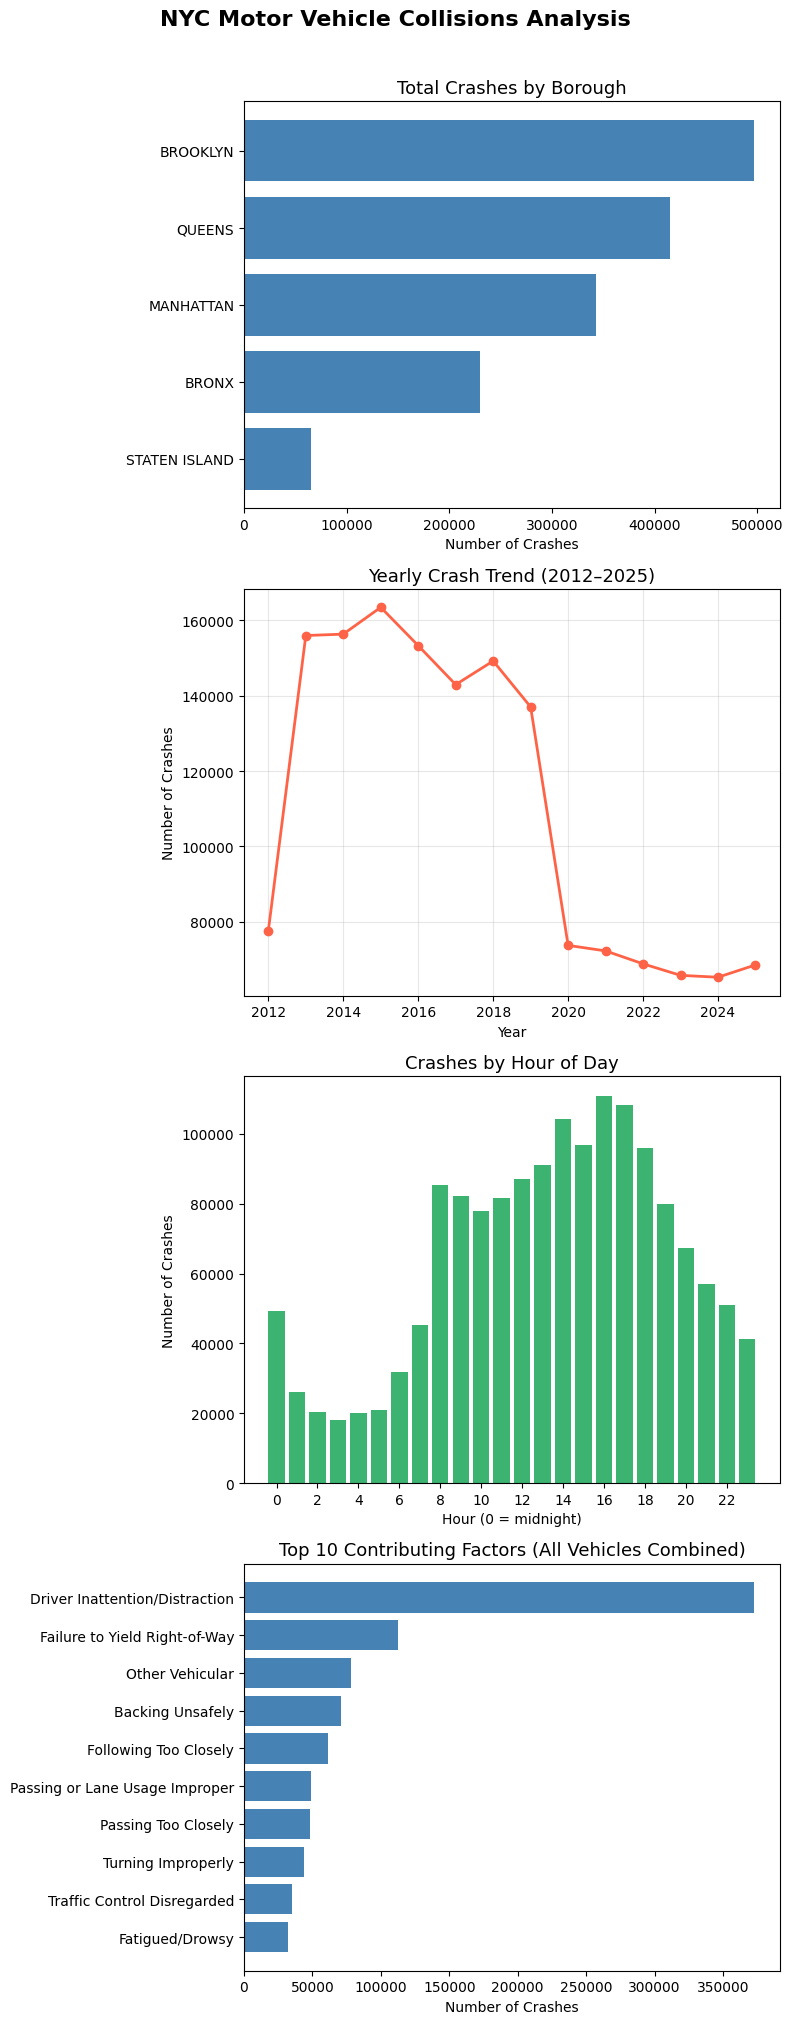

In [17]:
import matplotlib.pyplot as plt

#Collect aggregated results to Pandas for plotting
pd_borough = df_clean.groupBy("BOROUGH") \
    .count().orderBy(asc("count")).toPandas()

pd_yearly = df_clean.groupBy("CRASH_YEAR") \
    .count().orderBy(asc("CRASH_YEAR")).toPandas()

pd_hourly = df_clean.groupBy("CRASH_HOUR") \
    .count().orderBy(asc("CRASH_HOUR")).toPandas()

pd_factors = spark.sql("""
    SELECT factor, COUNT(*) as crash_count
    FROM (
        SELECT `CONTRIBUTING FACTOR VEHICLE 1` as factor FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 2` FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 3` FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 4` FROM collisions
        UNION ALL
        SELECT `CONTRIBUTING FACTOR VEHICLE 5` FROM collisions
    )
    WHERE factor IS NOT NULL
      AND factor != 'Unspecified'
    GROUP BY factor
    ORDER BY crash_count DESC
    LIMIT 10
""").toPandas()
pd_factors = pd_factors.sort_values("crash_count", ascending=True)

#4 charts, one per row
fig, axes = plt.subplots(4, 1, figsize=(8, 20))
fig.suptitle("NYC Motor Vehicle Collisions Analysis", fontsize=16, fontweight='bold', y=1.01)

#Chart 1: Total crashes by borough
axes[0].barh(pd_borough["BOROUGH"], pd_borough["count"], color='steelblue')
axes[0].set_title("Total Crashes by Borough", fontsize=13)
axes[0].set_xlabel("Number of Crashes")
axes[0].ticklabel_format(style='plain', axis='x')

#Chart 2: Yearly crash trend (2012-2025)
axes[1].plot(pd_yearly["CRASH_YEAR"], pd_yearly["count"],
             marker='o', color='tomato', linewidth=2)
axes[1].set_title("Yearly Crash Trend (2012–2025)", fontsize=13)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Crashes")
axes[1].grid(True, alpha=0.3)

#Chart 3: Crashes by hour of day
axes[2].bar(pd_hourly["CRASH_HOUR"], pd_hourly["count"], color='mediumseagreen')
axes[2].set_title("Crashes by Hour of Day", fontsize=13)
axes[2].set_xlabel("Hour (0 = midnight)")
axes[2].set_ylabel("Number of Crashes")
axes[2].set_xticks(range(0, 24, 2))

#Chart 4: Top 10 contributing factors (all vehicles combined)
axes[3].barh(pd_factors["factor"], pd_factors["crash_count"], color='steelblue')
axes[3].set_title("Top 10 Contributing Factors (All Vehicles Combined)", fontsize=13)
axes[3].set_xlabel("Number of Crashes")
axes[3].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

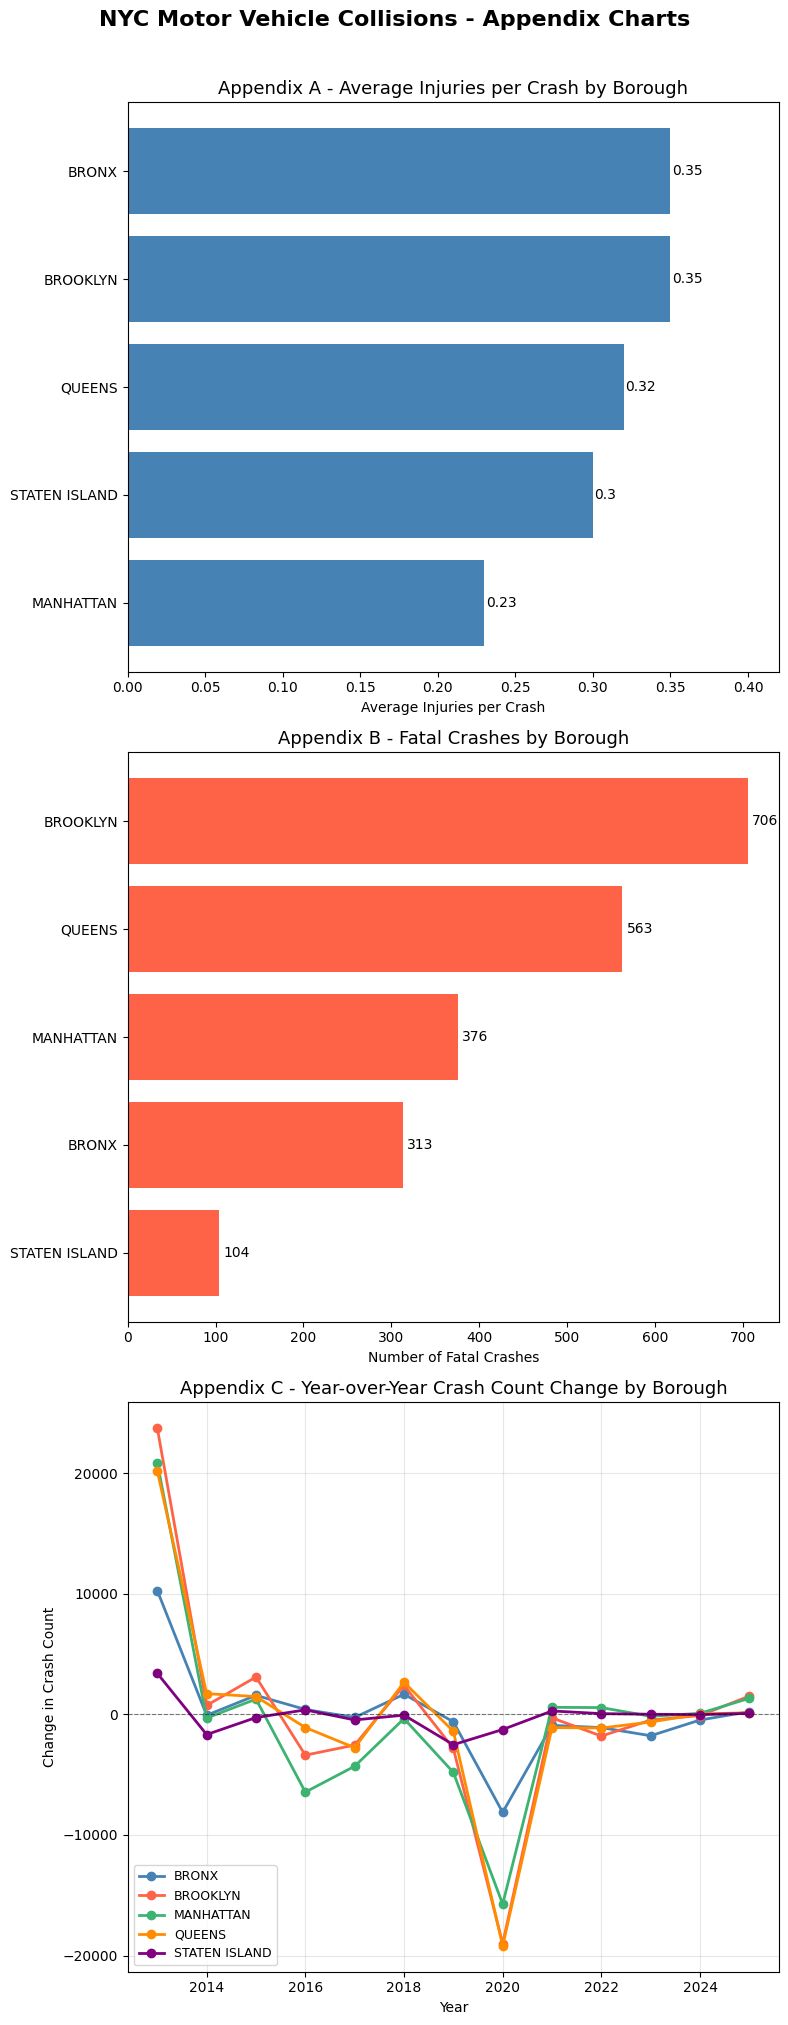

In [18]:
import matplotlib.pyplot as plt
from google.colab import files

#Convert table results toPanda

#Appendix A - Average injuries by borough
pd_avg_injuries = df_clean.groupBy("BOROUGH") \
    .agg(round(avg("NUMBER OF PERSONS INJURED"), 2).alias("avg_injuries")) \
    .orderBy(asc("avg_injuries")).toPandas()

#Appendix B - Fatal crashes by borough
pd_fatal = df_clean.filter(col("NUMBER OF PERSONS KILLED") > 0) \
    .groupBy("BOROUGH") \
    .agg(
        count("*").alias("fatal_crashes"),
        spark_sum("NUMBER OF PERSONS KILLED").alias("total_killed")
    ) \
    .orderBy(asc("fatal_crashes")).toPandas()

#Appendix C - Year-over-year crash change
pd_yoy = yoy_trend.filter(
    col("yoy_change").isNotNull() &
    col("BOROUGH").isNotNull()
).select("CRASH_YEAR", "BOROUGH", "yoy_change").toPandas()

#Plot Appendix visualization
fig, axes = plt.subplots(3, 1, figsize=(8, 20))
fig.suptitle("NYC Motor Vehicle Collisions - Appendix Charts",
             fontsize=16, fontweight='bold', y=1.01)

#Appendix A
axes[0].barh(pd_avg_injuries["BOROUGH"], pd_avg_injuries["avg_injuries"],
             color='steelblue')
axes[0].set_title("Appendix A - Average Injuries per Crash by Borough", fontsize=13)
axes[0].set_xlabel("Average Injuries per Crash")
axes[0].set_xlim(0, max(pd_avg_injuries["avg_injuries"]) * 1.2)
for i, v in enumerate(pd_avg_injuries["avg_injuries"]):
    axes[0].text(v + 0.001, i, str(v), va='center', fontsize=10)

#Appendix B
axes[1].barh(pd_fatal["BOROUGH"], pd_fatal["fatal_crashes"], color='tomato')
axes[1].set_title("Appendix B - Fatal Crashes by Borough", fontsize=13)
axes[1].set_xlabel("Number of Fatal Crashes")
axes[1].ticklabel_format(style='plain', axis='x')
for i, v in enumerate(pd_fatal["fatal_crashes"]):
    axes[1].text(v + 5, i, f"{v:,}", va='center', fontsize=10)

#Appendix C
colors = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange', 'purple']
boroughs = pd_yoy["BOROUGH"].unique()
for i, borough in enumerate(boroughs):
    borough_data = pd_yoy[pd_yoy["BOROUGH"] == borough].sort_values("CRASH_YEAR")
    axes[2].plot(borough_data["CRASH_YEAR"], borough_data["yoy_change"],
                 marker='o', label=borough, color=colors[i % len(colors)], linewidth=2)

axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[2].set_title("Appendix C - Year-over-Year Crash Count Change by Borough", fontsize=13)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Change in Crash Count")
axes[2].legend(loc='lower left', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
#Stop Spark session
spark.stop()
print("Spark session stopped.")

Spark session stopped.
